# LinkedIn Job Postings Data Analysis



## 1. Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset

In [25]:
import zipfile
import os

zip_path = "/content/job_postings.csv (1).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Extraction completed!")

Extraction completed!


In [26]:
import os

print("job_postings.csv exists:",
      os.path.exists("/content/job_postings.csv"))

if os.path.exists("/content/job_postings.csv"):
    print("CSV is ready!")

job_postings.csv exists: True
CSV is ready!


In [27]:
# Load the main LinkedIn Job Postings dataset

df = pd.read_csv("/content/job_postings.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 15886
Number of columns: 27


In [28]:
# Display first 5 rows

df.head()

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
0,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,NaN,45760.0,YEARLY,Full-time,"Chico, CA",...,1.710000e+12,NaN,NaN,NaN,1.690000e+12,NaN,1,FULL_TIME,USD,BASE_SALARY
1,133114754,77766802.0,Sales Manager,Are you a dynamic and creative marketing profe...,NaN,NaN,NaN,NaN,Full-time,"Santa Clarita, CA",...,1.700000e+12,NaN,NaN,NaN,1.690000e+12,NaN,0,FULL_TIME,NaN,NaN
2,133196985,1089558.0,Model Risk Auditor,Join Us as a Model Risk Auditor – Showcase You...,NaN,NaN,NaN,NaN,Contract,"New York, NY",...,1.700000e+12,NaN,NaN,NaN,1.690000e+12,NaN,0,CONTRACT,NaN,NaN
3,381055942,96654609.0,Business Manager,Business ManagerFirst Baptist Church ForneyFor...,NaN,NaN,NaN,NaN,Full-time,"Forney, TX",...,1.700000e+12,NaN,NaN,NaN,1.690000e+12,NaN,0,FULL_TIME,NaN,NaN
4,529257371,1244539.0,NY Studio Assistant,YOU COULD BE ONE OF THE MAGIC MAKERS\nKen Fulk...,NaN,NaN,NaN,NaN,Full-time,"New York, NY",...,1.710000e+12,NaN,NaN,NaN,1.690000e+12,NaN,1,FULL_TIME,NaN,NaN



## 3. Dataset Overview


In [29]:
# Dataset information

print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

Dataset Shape: (15886, 27)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15886 entries, 0 to 15885
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      15886 non-null  int64  
 1   company_id                  15520 non-null  float64
 2   title                       15886 non-null  object 
 3   description                 15885 non-null  object 
 4   max_salary                  5521 non-null   float64
 5   med_salary                  981 non-null    float64
 6   min_salary                  5521 non-null   float64
 7   pay_period                  6502 non-null   object 
 8   formatted_work_type         15886 non-null  object 
 9   location                    15886 non-null  object 
 10  applies                     8700 non-null   float64
 11  original_listed_time        15886 non-null  float64
 12  remote_allowed              2340 non-nu

In [30]:
# Statistical summary of numerical columns

df.describe()

,job_id,company_id,max_salary,med_salary,min_salary,applies,original_listed_time,remote_allowed,views,expiry,closed_time,listed_time,sponsored
count,1.588600e+04,1.552000e+04,5.521000e+03,981.000000,5521.000000,8700.000000,1.588600e+04,2340.0,13123.000000,1.588600e+04,9.280000e+02,1.588600e+04,15886.000000
mean,3.691293e+09,1.084100e+07,8.833622e+04,41167.664404,62352.218073,22.833103,1.690000e+12,1.0,76.776575,1.700765e+12,1.690000e+12,1.690000e+12,0.289248
std,1.028617e+08,2.313688e+07,9.068282e+04,93682.094905,59487.692283,54.892826,0.000000e+00,0.0,167.459105,2.709377e+09,0.000000e+00,0.000000e+00,0.453428
min,8.500877e+07,1.009000e+03,1.000000e+01,10.000000,10.000000,1.000000,1.690000e+12,1.0,1.000000,1.690000e+12,1.690000e+12,1.690000e+12,0.000000
25%,3.693071e+09,1.301100e+04,4.800000e+01,18.000000,38.000000,2.000000,1.690000e+12,1.0,6.000000,1.700000e+12,1.690000e+12,1.690000e+12,0.000000
50%,3.697358e+09,2.777685e+05,8.200000e+04,26.000000,60000.000000,6.000000,1.690000e+12,1.0,25.000000,1.700000e+12,1.690000e+12,1.690000e+12,0.000000
75%,3.699413e+09,7.798499e+06,1.400000e+05,52000.000000,99000.000000,21.000000,1.690000e+12,1.0,78.000000,1.700000e+12,1.690000e+12,1.690000e+12,1.000000
max,3.701374e+09,9.856222e+07,1.300000e+06,998426.000000,800000.000000,1615.000000,1.690000e+12,1.0,5656.000000,1.710000e+12,1.690000e+12,1.690000e+12,1.000000


In [31]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
job_id                            0
company_id                      366
title                             0
description                       1
max_salary                    10365
med_salary                    14905
min_salary                    10365
pay_period                     9384
formatted_work_type               0
location                          0
applies                        7186
original_listed_time              0
remote_allowed                13546
views                          2763
job_posting_url                   0
application_url                6091
application_type                  0
expiry                            0
closed_time                   14958
formatted_experience_level     4902
skills_desc                   15742
listed_time                       0
posting_domain                 6842
sponsored                         0
work_type                         0
currency                       9384
compensation_type              93

In [32]:
# Percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
skills_desc,15742,99.093541
closed_time,14958,94.158378
med_salary,14905,93.824751
remote_allowed,13546,85.270049
max_salary,10365,65.246129
min_salary,10365,65.246129
pay_period,9384,59.070880
compensation_type,9384,59.070880
currency,9384,59.070880
applies,7186,45.234798


## 4. Data Cleaning

In [33]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [34]:
# Remove the row with missing job description

df = df.dropna(subset=["description"])

print("Missing descriptions:", df["description"].isnull().sum())
print("Updated dataset shape:", df.shape)

Missing descriptions: 0
Updated dataset shape: (15885, 27)


In [36]:
# Fill missing experience levels

df["formatted_experience_level"] = df[
    "formatted_experience_level"
].fillna("Not Specified")

print("Missing experience levels:",
      df["formatted_experience_level"].isnull().sum())

print("\nExperience level distribution:")
print(df["formatted_experience_level"].value_counts())

Missing experience levels: 0

Experience level distribution:
formatted_experience_level
Mid-Senior level    5083
Not Specified       4901
Entry level         3694
Associate           1220
Director             687
Internship           166
Executive            134
Name: count, dtype: int64


In [37]:
# Create salary availability indicator

df["salary_available"] = df[
    ["min_salary", "med_salary", "max_salary"]
].notna().any(axis=1)

print("Salary availability:")
print(df["salary_available"].value_counts())

Salary availability:
salary_available
False    9383
True     6502
Name: count, dtype: int64


In [38]:
# Check remote work information

print("Remote work information:")
print(df["remote_allowed"].value_counts(dropna=False))

Remote work information:
remote_allowed
NaN    13545
1.0     2340
Name: count, dtype: int64


In [39]:
# Create a clean remote work status column

df["remote_status"] = df["remote_allowed"].map({
    1.0: "Remote"
}).fillna("Not Specified")

print("Remote work status:")
print(df["remote_status"].value_counts())

Remote work status:
remote_status
Not Specified    13545
Remote            2340
Name: count, dtype: int64


In [40]:
# Check for invalid negative values

numeric_columns = [
    "min_salary",
    "med_salary",
    "max_salary",
    "applies",
    "views"
]

for col in numeric_columns:
    print(f"{col}: {(df[col] < 0).sum()} negative values")

min_salary: 0 negative values
med_salary: 0 negative values
max_salary: 0 negative values
applies: 0 negative values
views: 0 negative values


In [41]:
# Check salary consistency

invalid_salary = (
    (df["min_salary"] > df["max_salary"])
    & df["min_salary"].notna()
    & df["max_salary"].notna()
)

print("Invalid salary records:", invalid_salary.sum())

Invalid salary records: 0


In [42]:
# Check important categorical columns

categorical_columns = [
    "title",
    "formatted_work_type",
    "location",
    "application_type",
    "work_type",
    "currency",
    "pay_period",
    "compensation_type"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print("Blank values:", (df[col].astype(str).str.strip() == "").sum())
    print(df[col].value_counts(dropna=False).head(10))


--- title ---
Blank values: 0
title
Sales Director [Owner/Operator]    83
Sales Associate                    64
Retail Sales Associate             60
Sales Director {Owner/Operator}    54
Project Manager                    40
Administrative Assistant           40
Staff Accountant                   40
Customer Service Representative    39
Call Center Support Rep            38
Senior Accountant                  37
Name: count, dtype: int64

--- formatted_work_type ---
Blank values: 0
formatted_work_type
Full-time     12843
Contract       1739
Part-time      1010
Temporary       121
Internship      111
Other            53
Volunteer         8
Name: count, dtype: int64

--- location ---
Blank values: 0
location
United States      1133
New York, NY        398
Chicago, IL         267
Houston, TX         243
Atlanta, GA         207
Los Angeles, CA     188
Dallas, TX          182
Austin, TX          168
Boston, MA          147
San Diego, CA       137
Name: count, dtype: int64

--- application_

In [43]:
# Clean text columns

text_columns = [
    "title",
    "formatted_work_type",
    "location",
    "application_type",
    "work_type",
    "currency",
    "pay_period",
    "compensation_type",
    "formatted_experience_level"
]

for col in text_columns:
    df[col] = df[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


In [44]:
# Create a cleaned job title column

df["clean_title"] = (
    df["title"]
    .str.strip()
    .str.lower()
)

print("Clean title column created successfully!")
print(df[["title", "clean_title"]].head(10))

Clean title column created successfully!
                              title                       clean_title
0          Licensed Insurance Agent          licensed insurance agent
1                     Sales Manager                     sales manager
2                Model Risk Auditor                model risk auditor
3                  Business Manager                  business manager
4               NY Studio Assistant               ny studio assistant
5                  Office Associate                  office associate
6                 Education Manager                 education manager
7                    Civil Engineer                    civil engineer
8  Registered Nurse (RN) Vaccinator  registered nurse (rn) vaccinator
9                     Company Owner                     company owner


In [45]:
# Create salary range

df["salary_range"] = df["max_salary"] - df["min_salary"]

print("Salary range created successfully!")
print(df[["min_salary", "max_salary", "salary_range"]].head(10))

Salary range created successfully!
   min_salary  max_salary  salary_range
0     45760.0     52000.0        6240.0
1         NaN         NaN           NaN
2         NaN         NaN           NaN
3         NaN         NaN           NaN
4         NaN         NaN           NaN
5     37000.0     42000.0        5000.0
6         NaN         NaN           NaN
7         NaN         NaN           NaN
8        50.0        50.0           0.0
9         NaN         NaN           NaN


In [46]:
# Create a representative salary column

df["representative_salary"] = df["med_salary"]

df["representative_salary"] = df["representative_salary"].fillna(
    (df["min_salary"] + df["max_salary"]) / 2
)

print("Representative salary created successfully!")
print(
    df[
        ["min_salary", "med_salary", "max_salary", "representative_salary"]
    ].head(10)
)

Representative salary created successfully!
   min_salary  med_salary  max_salary  representative_salary
0     45760.0         NaN     52000.0                48880.0
1         NaN         NaN         NaN                    NaN
2         NaN         NaN         NaN                    NaN
3         NaN         NaN         NaN                    NaN
4         NaN         NaN         NaN                    NaN
5     37000.0         NaN     42000.0                39500.0
6         NaN         NaN         NaN                    NaN
7         NaN         NaN         NaN                    NaN
8        50.0         NaN        50.0                   50.0
9         NaN         NaN         NaN                    NaN


In [47]:
# Create salary status

df["salary_status"] = df["salary_available"].map({
    True: "Salary Available",
    False: "Salary Not Specified"
})

print("Salary status created successfully!")
print(df["salary_status"].value_counts())

Salary status created successfully!
salary_status
Salary Not Specified    9383
Salary Available        6502
Name: count, dtype: int64


In [48]:
# Convert listed_time into a proper date

df["listed_date"] = pd.to_datetime(
    df["listed_time"],
    unit="ms"
)

print("Listed date created successfully!")
print(df[["listed_time", "listed_date"]].head(10))

Listed date created successfully!
    listed_time         listed_date
0  1.690000e+12 2023-07-22 04:26:40
1  1.690000e+12 2023-07-22 04:26:40
2  1.690000e+12 2023-07-22 04:26:40
3  1.690000e+12 2023-07-22 04:26:40
4  1.690000e+12 2023-07-22 04:26:40
5  1.690000e+12 2023-07-22 04:26:40
6  1.690000e+12 2023-07-22 04:26:40
7  1.690000e+12 2023-07-22 04:26:40
8  1.690000e+12 2023-07-22 04:26:40
9  1.690000e+12 2023-07-22 04:26:40


In [49]:
# Create year and month columns

df["listed_year"] = df["listed_date"].dt.year
df["listed_month"] = df["listed_date"].dt.month
df["listed_month_name"] = df["listed_date"].dt.month_name()

print("Year and month columns created successfully!")
print(df[["listed_date", "listed_year", "listed_month", "listed_month_name"]].head(10))

Year and month columns created successfully!
          listed_date  listed_year  listed_month listed_month_name
0 2023-07-22 04:26:40         2023             7              July
1 2023-07-22 04:26:40         2023             7              July
2 2023-07-22 04:26:40         2023             7              July
3 2023-07-22 04:26:40         2023             7              July
4 2023-07-22 04:26:40         2023             7              July
5 2023-07-22 04:26:40         2023             7              July
6 2023-07-22 04:26:40         2023             7              July
7 2023-07-22 04:26:40         2023             7              July
8 2023-07-22 04:26:40         2023             7              July
9 2023-07-22 04:26:40         2023             7              July


In [50]:
# Check for duplicate job IDs

duplicate_job_ids = df["job_id"].duplicated().sum()

print("Duplicate job IDs:", duplicate_job_ids)

Duplicate job IDs: 0


In [51]:
# Final dataset overview after cleaning

print("Final dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Final dataset shape: (15885, 37)

Columns:
['job_id', 'company_id', 'title', 'description', 'max_salary', 'med_salary', 'min_salary', 'pay_period', 'formatted_work_type', 'location', 'applies', 'original_listed_time', 'remote_allowed', 'views', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'salary_available', 'remote_status', 'clean_title', 'salary_range', 'representative_salary', 'salary_status', 'listed_date', 'listed_year', 'listed_month', 'listed_month_name']

Missing values:
skills_desc              15741
closed_time              14957
med_salary               14904
remote_allowed           13545
max_salary               10364
min_salary               10364
salary_range             10364
compensation_type         9383
pay_period                9383
currency                  9383
representative_salary     9383


In [52]:
# Top 15 most common job titles

top_titles = df["clean_title"].value_counts().head(15)

print("Top 15 Job Titles:")
print(top_titles)

Top 15 Job Titles:
clean_title
sales director [owner/operator]    83
sales director {owner/operator}    78
sales associate                    65
retail sales associate             60
staff accountant                   42
project manager                    41
administrative assistant           40
customer service representative    39
call center support rep            38
executive assistant                38
senior accountant                  37
scoring content specialist         36
sales manager                      34
account executive                  34
controller                         30
Name: count, dtype: int64


In [53]:
# Further clean job titles

df["clean_title"] = (
    df["title"]
    .str.lower()
    .str.replace(r"[\[\]\{\}\(\)]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Updated job titles:")
print(df["clean_title"].value_counts().head(15))

Updated job titles:
clean_title
sales director owner/operator                           161
sales associate                                          65
retail sales associate                                   60
staff accountant                                         42
project manager                                          41
administrative assistant                                 40
customer service representative                          39
call center support rep                                  38
executive assistant                                      38
senior accountant                                        37
scoring content specialist                               36
account executive                                        34
sales manager                                            34
controller                                               30
general superintendent, mission critical - traveling     29
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)


### 5.1 Job Categories

In [54]:
# Top 15 most common job titles

top_titles = df["clean_title"].value_counts().head(15)

print("Top 15 Most Common Job Titles:")
print(top_titles)

Top 15 Most Common Job Titles:
clean_title
sales director owner/operator                           161
sales associate                                          65
retail sales associate                                   60
staff accountant                                         42
project manager                                          41
administrative assistant                                 40
customer service representative                          39
call center support rep                                  38
executive assistant                                      38
senior accountant                                        37
scoring content specialist                               36
account executive                                        34
sales manager                                            34
controller                                               30
general superintendent, mission critical - traveling     29
Name: count, dtype: int64


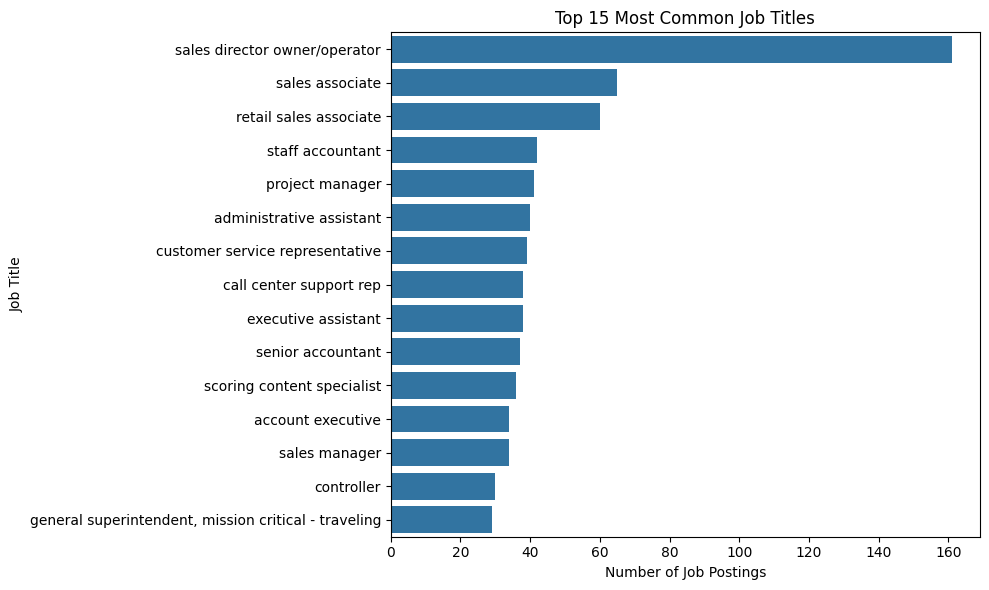

In [55]:
# Visualize top 15 job titles

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_titles.values,
    y=top_titles.index
)

plt.title("Top 15 Most Common Job Titles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

In [56]:
# Job postings by work type

work_type_counts = df["work_type"].value_counts()

print("Job Postings by Work Type:")
print(work_type_counts)

Job Postings by Work Type:
work_type
FULL_TIME     12843
CONTRACT       1739
PART_TIME      1010
TEMPORARY       121
INTERNSHIP      111
OTHER            53
VOLUNTEER         8
Name: count, dtype: int64


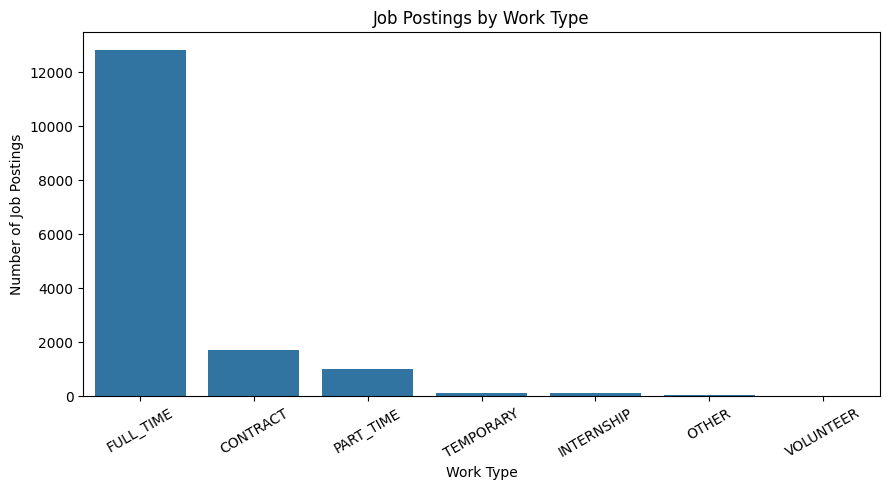

In [57]:
# Visualize work type distribution

plt.figure(figsize=(9, 5))

sns.barplot(
    x=work_type_counts.index,
    y=work_type_counts.values
)

plt.title("Job Postings by Work Type")
plt.xlabel("Work Type")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


### 5.2 Job Locations

In [58]:
# Top 15 job locations

top_locations = df["location"].value_counts().head(15)

print("Top 15 Job Locations:")
print(top_locations)

Top 15 Job Locations:
location
United States                      1133
New York, NY                        398
Chicago, IL                         267
Houston, TX                         243
Atlanta, GA                         207
Los Angeles, CA                     188
Dallas, TX                          182
Austin, TX                          168
Boston, MA                          147
San Diego, CA                       137
New York City Metropolitan Area     136
Seattle, WA                         133
Phoenix, AZ                         132
San Francisco, CA                   130
Charlotte, NC                       125
Name: count, dtype: int64


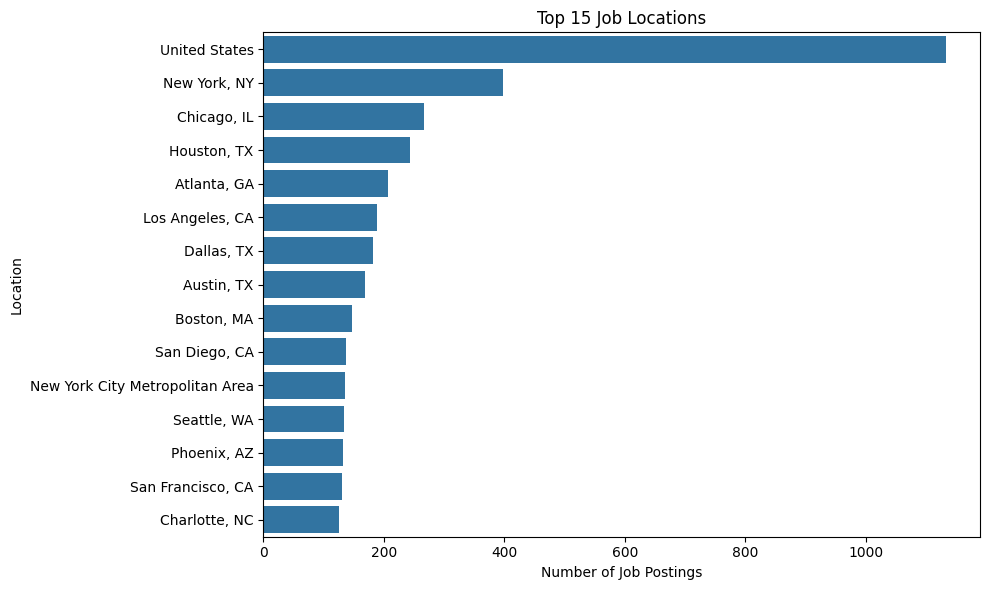

In [59]:
# Visualize top 15 job locations

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top 15 Job Locations")
plt.xlabel("Number of Job Postings")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

In [60]:
# Top 10 locations and their percentage of total postings

top_10_locations = df["location"].value_counts().head(10)

location_percentage = (
    top_10_locations / len(df) * 100
).round(2)

location_summary = pd.DataFrame({
    "Job Postings": top_10_locations,
    "Percentage": location_percentage
})

print("Top 10 Locations:")
print(location_summary)

Top 10 Locations:
                 Job Postings  Percentage
location                                 
United States            1133        7.13
New York, NY              398        2.51
Chicago, IL               267        1.68
Houston, TX               243        1.53
Atlanta, GA               207        1.30
Los Angeles, CA           188        1.18
Dallas, TX                182        1.15
Austin, TX                168        1.06
Boston, MA                147        0.93
San Diego, CA             137        0.86


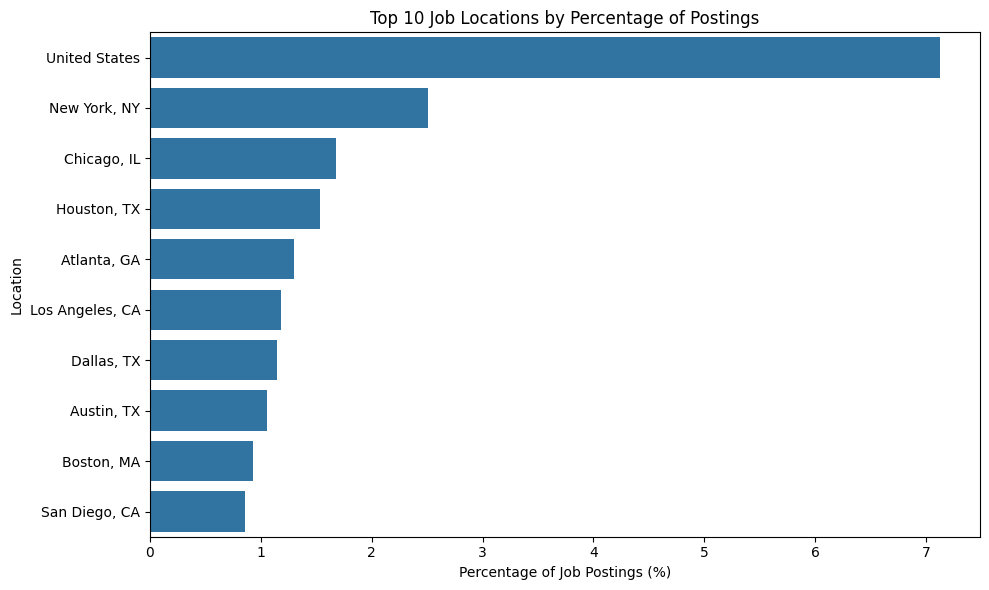

In [61]:
# Visualize percentage of job postings by top 10 locations

plt.figure(figsize=(10, 6))

sns.barplot(
    x=location_summary["Percentage"],
    y=location_summary.index
)

plt.title("Top 10 Job Locations by Percentage of Postings")
plt.xlabel("Percentage of Job Postings (%)")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

### 5.3 Company Analysis

In [62]:
# Top 15 companies by number of job postings

top_companies = df["company_id"].value_counts().head(15)

print("Top 15 Companies by Job Postings:")
print(top_companies)

Top 15 Companies by Job Postings:
company_id
3570660.0     161
1103.0        113
11056.0       108
1441.0         93
1586.0         93
10420321.0     92
18506580.0     71
1403.0         70
6176.0         68
1681.0         56
26923.0        54
3671.0         52
7795.0         52
77301.0        52
11229.0        50
Name: count, dtype: int64


In [63]:
# Load company information

companies = pd.read_csv("/content/companies.csv")

print("Companies dataset shape:", companies.shape)
print("\nColumns:")
print(companies.columns.tolist())

print("\nFirst 5 rows:")
print(companies.head())

Companies dataset shape: (6063, 10)

Columns:
['company_id', 'name', 'description', 'company_size', 'state', 'country', 'city', 'zip_code', 'address', 'url']

First 5 rows:
   company_id                        name  \
0        1009                         IBM   
1        1016               GE HealthCare   
2        1021                    GE Power   
3        1025  Hewlett Packard Enterprise   
4        1028                      Oracle   

                                         description  company_size  state  \
0  At IBM, we do more than work. We create. We cr...           7.0     NY   
1  Every day millions of people feel the impact o...           7.0      0   
2  GE Power, part of GE Vernova, is a world energ...           7.0     NY   
3  Official LinkedIn of Hewlett Packard Enterpris...           7.0  Texas   
4  We’re a cloud technology company that provides...           7.0  Texas   

  country              city zip_code                                address  \
0      US  Arm

In [64]:
# Merge company names with job postings

df = df.merge(
    companies[["company_id", "name"]],
    on="company_id",
    how="left"
)

# Rename company column
df.rename(columns={"name": "company_name"}, inplace=True)

print("Company information merged successfully!")
print(df[["company_id", "company_name"]].head(10))

Company information merged successfully!
   company_id                     company_name
0         NaN                              NaN
1  77766802.0                      CargoLogin.
2   1089558.0                Employvision Inc.
3  96654609.0      First Baptist Church Forney
4   1244539.0                     Ken Fulk Inc
5   3894635.0                  Sunnyland Farms
6  18995316.0         Paradigm Senior Services
7    882349.0  Eric L. Davis Engineering, Inc.
8     61469.0  United Staffing Solutions (USS)
9         NaN                              NaN


In [65]:
# Count job postings for each company

top_company_names = (
    df["company_name"]
    .dropna()
    .value_counts()
    .head(15)
)

print("Top 15 Companies by Number of Job Postings:")
print(top_company_names)

Top 15 Companies by Number of Job Postings:
company_name
City Lifestyle                    161
Verizon                           113
Insight Global                    108
Amazon                             93
Google                             93
The Mom Project                    92
Vivian Health                      71
Booz Allen Hamilton                70
7-Eleven                           68
Robert Half                        56
Holiday Stationstores              54
H&R Block                          52
Petco                              52
Raising Cane's Chicken Fingers     52
Vaco                               50
Name: count, dtype: int64


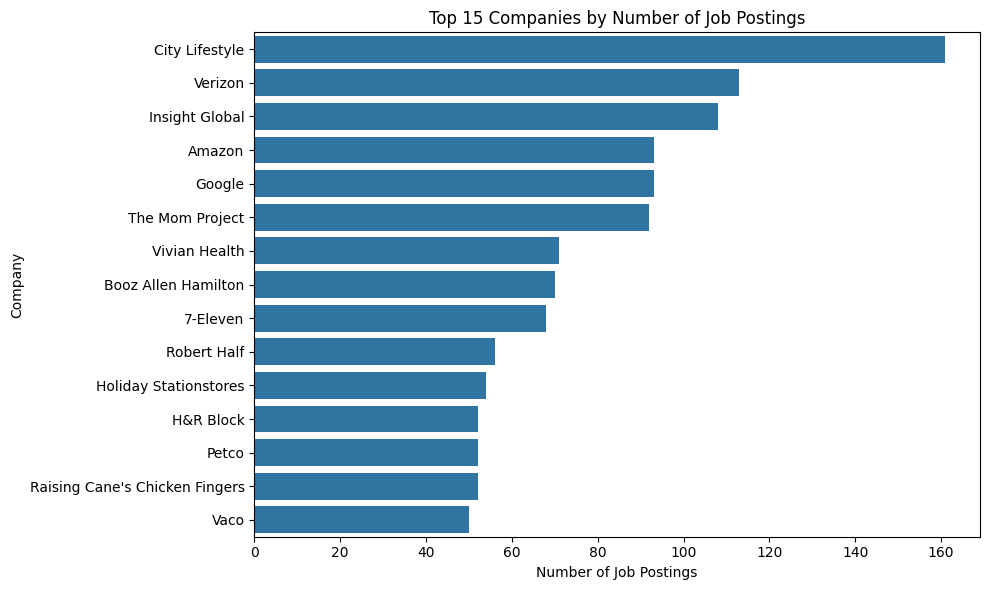

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_company_names.values,
    y=top_company_names.index
)

plt.title("Top 15 Companies by Number of Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

In [67]:
company_size_counts = companies["company_size"].value_counts().sort_index()

print("Company Size Distribution:")
print(company_size_counts)

Company Size Distribution:
company_size
1.0     937
2.0    1079
3.0     648
4.0     528
5.0    1060
6.0     397
7.0     825
Name: count, dtype: int64


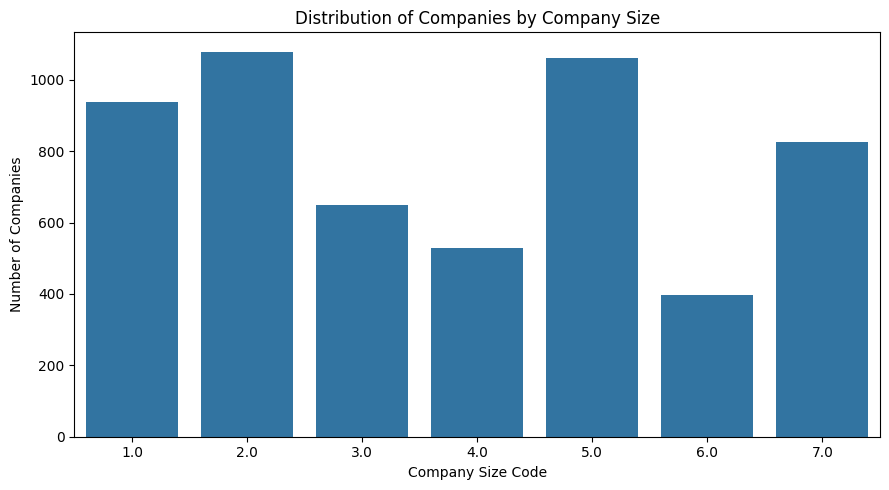

In [68]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=company_size_counts.index,
    y=company_size_counts.values
)

plt.title("Distribution of Companies by Company Size")
plt.xlabel("Company Size Code")
plt.ylabel("Number of Companies")

plt.tight_layout()
plt.show()

### 5.4 Experience & Skills

In [69]:
experience_counts = df["formatted_experience_level"].value_counts()

print("Job Postings by Experience Level:")
print(experience_counts)

Job Postings by Experience Level:
formatted_experience_level
Mid-Senior level    5083
Not Specified       4901
Entry level         3694
Associate           1220
Director             687
Internship           166
Executive            134
Name: count, dtype: int64


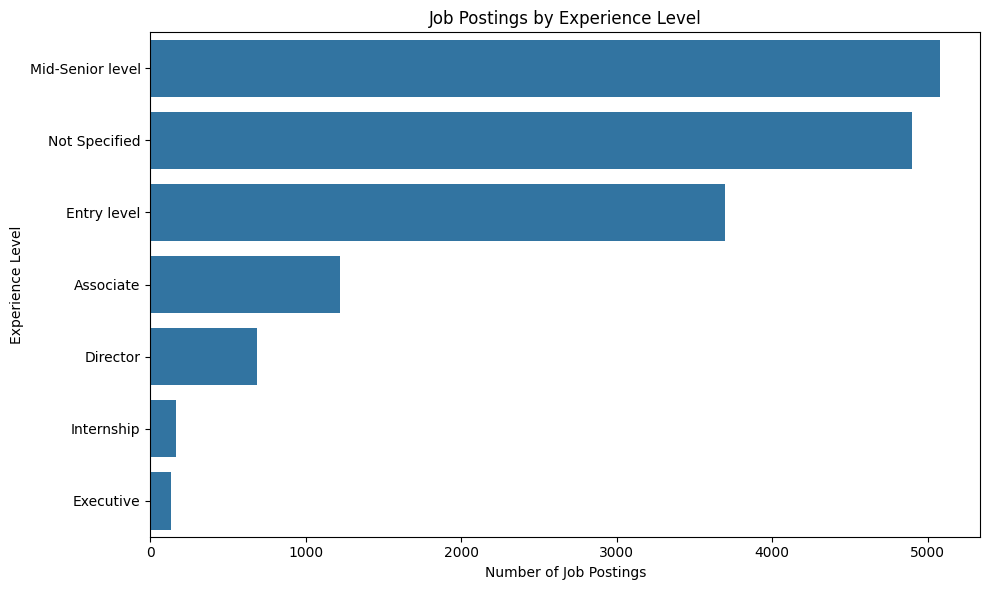

In [70]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=experience_counts.values,
    y=experience_counts.index
)

plt.title("Job Postings by Experience Level")
plt.xlabel("Number of Job Postings")
plt.ylabel("Experience Level")

plt.tight_layout()
plt.show()

In [71]:
job_skills = pd.read_csv("/content/job_skills.csv")

print("Job Skills dataset shape:", job_skills.shape)

print("\nColumns:")
print(job_skills.columns.tolist())

print("\nFirst 5 rows:")
print(job_skills.head())

Job Skills dataset shape: (27899, 2)

Columns:
['job_id', 'skill_abr']

First 5 rows:
       job_id skill_abr
0  3690843087      ACCT
1  3690843087       FIN
2  3691763971      MGMT
3  3691763971      MNFC
4  3691775263      MGMT


In [72]:
top_skills = job_skills["skill_abr"].value_counts().head(15)

print("Top 15 Most In-Demand Skills:")
print(top_skills)

Top 15 Most In-Demand Skills:
skill_abr
IT      3841
SALE    2904
MGMT    2467
MNFC    2195
BD      1993
ENG     1974
OTHR    1574
HCPR    1346
FIN     1227
ACCT     813
MRKT     802
PRJM     630
ADM      589
ANLS     479
RSCH     430
Name: count, dtype: int64


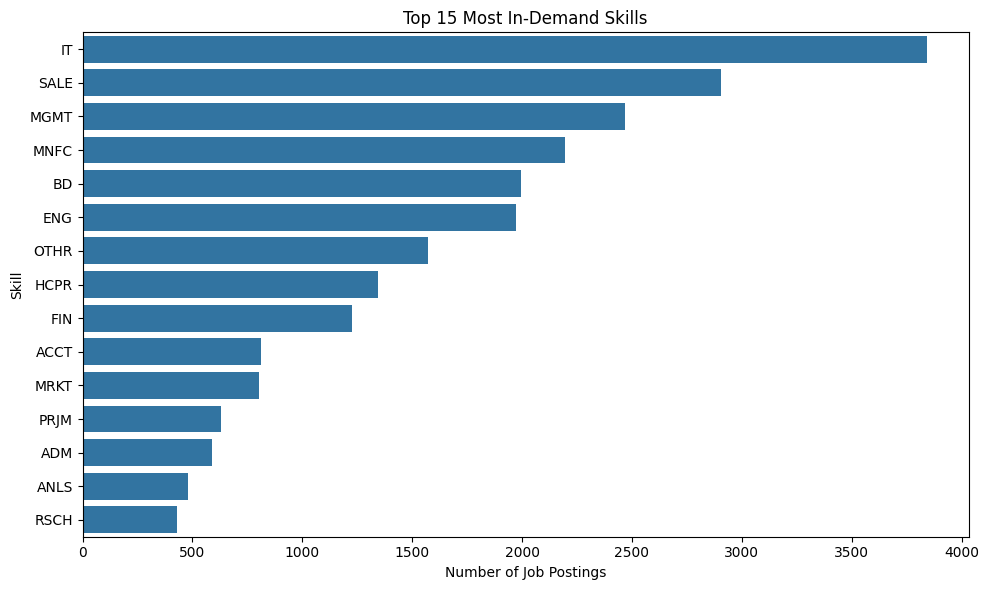

In [74]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_skills.values,
    y=top_skills.index
)

plt.title("Top 15 Most In-Demand Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

### 5.5 Salary Analysis

Salary Availability:
salary_status
Salary Not Specified    9383
Salary Available        6502
Name: count, dtype: int64


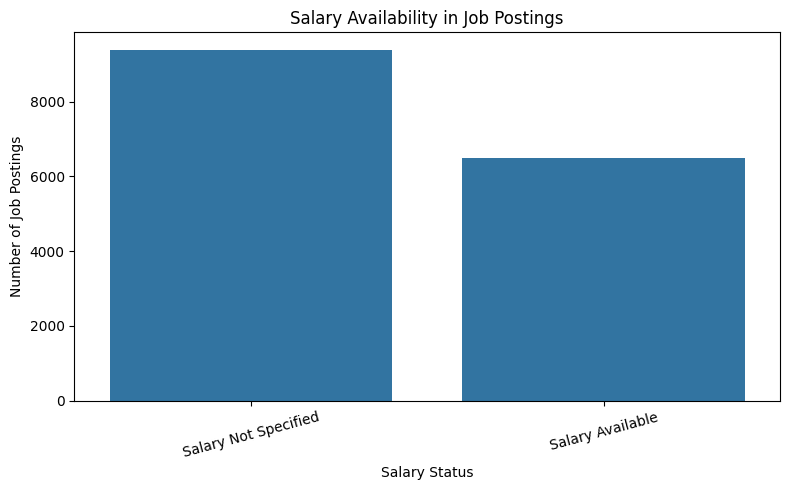

In [75]:
salary_counts = df["salary_status"].value_counts()

print("Salary Availability:")
print(salary_counts)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=salary_counts.index,
    y=salary_counts.values
)
plt.title("Salary Availability in Job Postings")
plt.xlabel("Salary Status")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Salary Statistics:
count    6.502000e+03
mean     7.018778e+04
std      7.763898e+04
min      1.000000e+01
25%      3.129375e+01
50%      6.500000e+04
75%      1.150000e+05
max      1.050000e+06
Name: representative_salary, dtype: float64


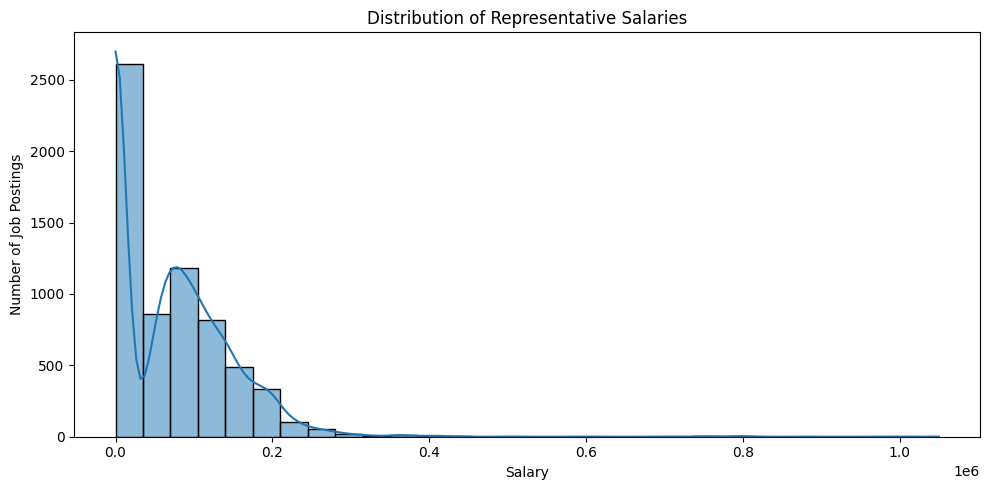

In [76]:
salary_data = df["representative_salary"].dropna()

print("Salary Statistics:")
print(salary_data.describe())

plt.figure(figsize=(10, 5))
sns.histplot(salary_data, bins=30, kde=True)

plt.title("Distribution of Representative Salaries")
plt.xlabel("Salary")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

Average Salary by Experience Level:
formatted_experience_level
Executive           177259.684462
Director            172759.952525
Mid-Senior level     87463.587822
Not Specified        66013.408493
Associate            52147.081905
Entry level          32322.678713
Internship           11517.559898
Name: representative_salary, dtype: float64


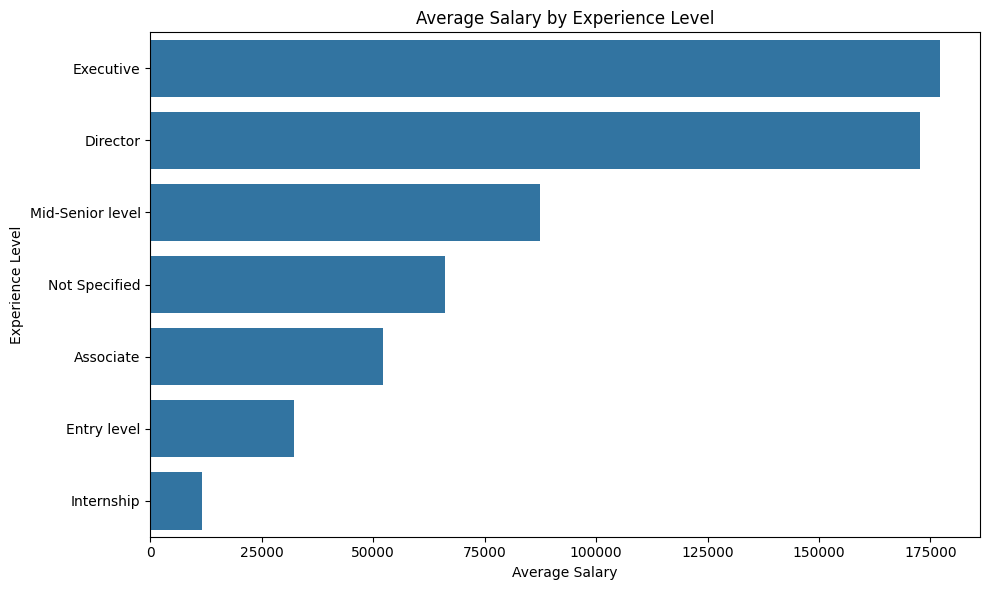

In [78]:
salary_by_experience = (
    df.groupby("formatted_experience_level")["representative_salary"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

print("Average Salary by Experience Level:")
print(salary_by_experience)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=salary_by_experience.values,
    y=salary_by_experience.index
)

plt.title("Average Salary by Experience Level")
plt.xlabel("Average Salary")
plt.ylabel("Experience Level")

plt.tight_layout()
plt.show()

### 5.6 Remote/On-site Jobs

Remote Work Status:
remote_status
Not Specified    13545
Remote            2340
Name: count, dtype: int64


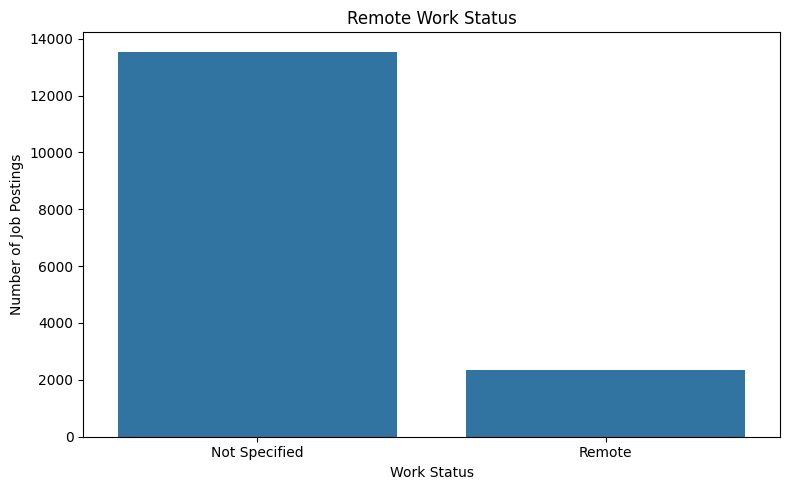

In [79]:
remote_counts = df["remote_status"].value_counts()

print("Remote Work Status:")
print(remote_counts)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=remote_counts.index,
    y=remote_counts.values
)

plt.title("Remote Work Status")
plt.xlabel("Work Status")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

Remote Work by Experience Level:
remote_status               Not Specified  Remote
formatted_experience_level                       
Associate                            1043     177
Director                              580     107
Entry level                          3479     215
Executive                             110      24
Internship                            161       5
Mid-Senior level                     4158     925
Not Specified                        4014     887


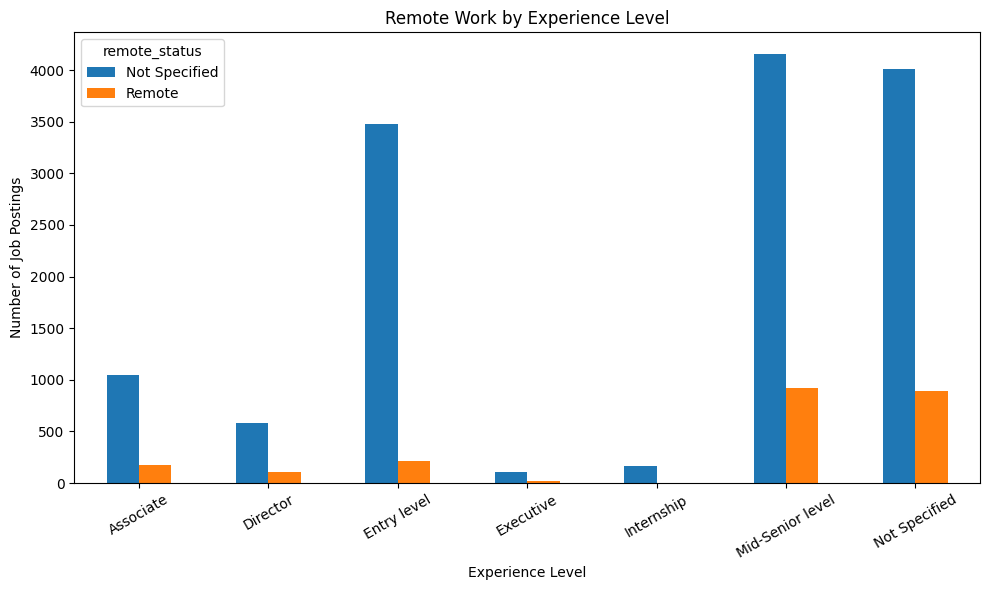

In [80]:
remote_experience = pd.crosstab(
    df["formatted_experience_level"],
    df["remote_status"]
)

print("Remote Work by Experience Level:")
print(remote_experience)

remote_experience.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Remote Work by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. Key Insights


- Full-time jobs were the most common type of employment in the dataset.
- Sales-related and other business-oriented roles appeared frequently among job postings.
- Major job locations included the United States, New York, Chicago, Houston, and Atlanta.
- Mid-Senior level and Entry level positions represented a large share of the job postings.
- IT, Sales, Management, Manufacturing, and Business Development were among the most frequently associated skills.
- Salary information was available for only a portion of the job postings, while many postings did not specify salary details.
- Salary levels varied across different experience levels.
- A significant number of postings did not specify their remote-work status, while a smaller portion explicitly allowed remote work.
- The analysis shows that job opportunities vary considerably by role, location, experience level, skills, and employment type.

## 7. Conclusion

This analysis explored LinkedIn job postings to identify patterns in job categories, locations, companies, experience levels, skills, salaries, and remote-work opportunities. Data cleaning and exploratory analysis helped identify important employment trends and characteristics of the job market.

The project demonstrates how Python, Pandas, NumPy, Matplotlib, and Seaborn can be used to transform raw job-posting data into meaningful insights. These findings can help understand the skills, experience levels, locations, and employment types commonly associated with job opportunities.

# Saving cleaned dataset.

In [81]:
# Save cleaned dataset

df.to_csv("/content/linkedin_job_postings_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Shape:", df.shape)

Cleaned dataset saved successfully!
Shape: (15885, 38)
